# Machine Learning - Day 1

## Topics Covered
- NumPy Basics
- NumPy Operations
- Linear Regression
- Logistic Regression
- Decision Trees

**Goal:** Learn the fundamentals of Machine Learning by writing and understanding every line of code.

# 1. NumPy

## Description

NumPy (Numerical Python) is the fundamental library for numerical computing in Python. It provides fast, memory-efficient multidimensional arrays and mathematical functions that are widely used in Machine Learning, Data Science, and Artificial Intelligence.

### Why NumPy is used in Machine Learning?

- Efficient storage and manipulation of numerical data.
- Faster mathematical computations than Python lists.
- Supports vectors, matrices, and linear algebra operations.
- Forms the foundation for libraries like Pandas, Scikit-learn, TensorFlow, and PyTorch.

In [6]:
import numpy as np

print("NumPy imported successfully!")

NumPy imported successfully!


In [7]:
import numpy as np

arr = np.array([1, 2, 3, 4, 5])

print(arr)

[1 2 3 4 5]


In [8]:
import numpy as np

# 1-D vector — shape (3,)
v = np.array([1, 2, 3])
print(v.shape)

# 2-D matrix — shape (rows, cols)
M = np.array([[1, 2, 3],
              [4, 5, 6]])
print(M.shape)

# Common constructors
zeros = np.zeros((3, 3))
ones = np.ones((2, 4))
rng = np.arange(0, 10, 2)
rand = np.random.randn(5, 5)

(3,)
(2, 3)


In [9]:
import numpy as np

np.random.seed(42)

X = np.random.randn(100, 5)      # 100 samples, 5 features
y = np.random.randn(100)         # 100 targets

# Matrix multiply — the core of every linear model
w = np.random.randn(5)

predictions = X @ w              # shape (100,) — one score per sample

# Standardise columns (zero mean, unit variance)
X_scaled = (X - X.mean(axis=0)) / X.std(axis=0)

# Train/test split manually
X_train, X_test = X[:80], X[80:]
y_train, y_test = y[:80], y[80:]

print(X_train.shape, X_test.shape)

(80, 5) (20, 5)


# 2. Linear Regression

## Description

Linear Regression is a supervised machine learning algorithm used to predict continuous numerical values. It learns the relationship between input features and the target variable by fitting the best possible straight line through the data.

### Applications

- House Price Prediction
- Salary Prediction
- Sales Forecasting
- Stock Price Estimation

## Import Libraries

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

## Generate Synthetic Dataset

In [13]:
np.random.seed(42)

n = 200
size = np.random.uniform(500, 3500, n)
price = 150 * size + 20000 + np.random.randn(n) * 30000

## Manual Linear Regression

In [14]:
w_manual = np.cov(size, price)[0, 1] / np.var(size)
b_manual = price.mean() - w_manual * size.mean()

print(f"Manual: w={w_manual:.1f}, b={b_manual:.0f}")

Manual: w=150.0, b=22083


## Scikit-Learn Linear Regression

In [15]:
X2d = size.reshape(-1, 1)

model = LinearRegression()
model.fit(X2d, price)

print(f"sklearn: w={model.coef_[0]:.1f}, b={model.intercept_:.0f}")

sklearn: w=149.2, b=23546


## Model Evaluation

In [16]:
y_pred = model.predict(X2d)

print(f"MSE: {mean_squared_error(price, y_pred):.0f}")
print(f"R2: {r2_score(price, y_pred):.4f}")

MSE: 840443581
R2: 0.9538


## Data Visualization

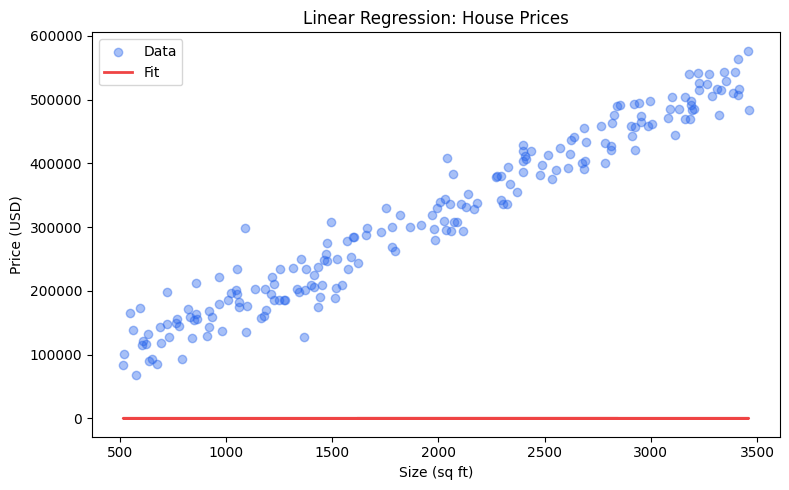

In [23]:
plt.figure(figsize=(8, 5))

plt.scatter(size, price, alpha=0.4, color="#2563EB", label="Data")
plt.plot(size, y_pred, color="#EF4444", lw=2, label="Fit")

plt.xlabel("Size (sq ft)")
plt.ylabel("Price (USD)")
plt.title("Linear Regression: House Prices")

plt.legend()
plt.tight_layout()
plt.savefig("regression.png", dpi=120)
plt.show()

# 3. Logistic Regression

## Description

Logistic Regression is a supervised machine learning algorithm used for classification problems. Unlike Linear Regression, which predicts continuous numerical values, Logistic Regression predicts the probability that an input belongs to a particular class.

### Applications

- Spam Email Detection
- Disease Prediction
- Customer Churn Prediction
- Fraud Detection
- Customer Purchase Prediction

## Impot Libraries

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## Generate Dataset

In [19]:
# Reproducibility
np.random.seed(42)

# Generate synthetic dataset
n = 200

X = np.random.randn(n, 2)

# Decision boundary
y = (X[:, 0] + X[:, 1] > 0).astype(int)

## Train Logistic Regression

In [20]:
model = LogisticRegression()

model.fit(X, y)

y_pred = model.predict(X)

## Evaluate Model

In [21]:
print("Accuracy:", accuracy_score(y, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y, y_pred))

print("\nClassification Report:")
print(classification_report(y, y_pred))

Accuracy: 1.0

Confusion Matrix:
[[100   0]
 [  0 100]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       1.00      1.00      1.00       100

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



## Visualization

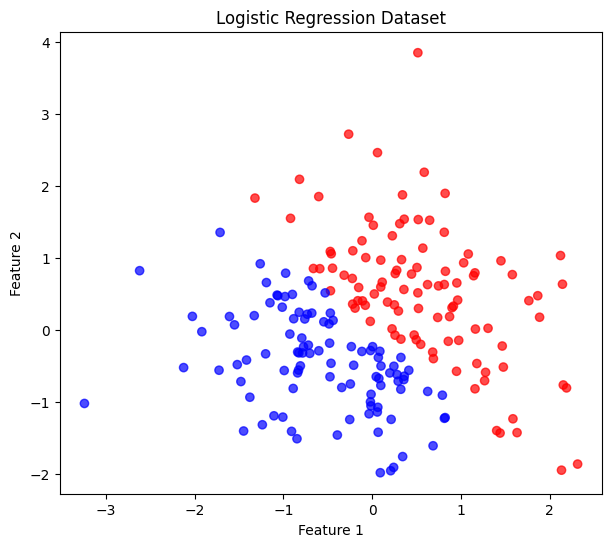

In [22]:
plt.figure(figsize=(7, 6))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=y,
    cmap="bwr",
    alpha=0.7
)

plt.title("Logistic Regression Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.show()

## Conclusion

- Logistic Regression is a supervised learning algorithm used for classification.
- It predicts the probability that a sample belongs to a class.
- The model is trained using labeled data.
- Model performance can be evaluated using Accuracy, Confusion Matrix, and Classification Report.

# 4. Decision Tree

## Description

A Decision Tree is a supervised machine learning algorithm used for both classification and regression tasks. It makes predictions by splitting the data into smaller subsets based on feature values, creating a tree-like structure of decisions.

### Applications

- Loan Approval
- Medical Diagnosis
- Customer Segmentation
- Fraud Detection
- Credit Risk Analysis

## Import Libraries

In [24]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

## Generate Dataset

In [25]:
np.random.seed(42)

X, y = make_classification(
    n_samples=200,
    n_features=2,
    n_redundant=0,
    n_clusters_per_class=1,
    random_state=42
)

## Training Decision Trees

In [26]:
model = DecisionTreeClassifier(random_state=42)

model.fit(X, y)

y_pred = model.predict(X)

## Model Evaluaton

In [27]:
print("Accuracy:", accuracy_score(y, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y, y_pred))

print("\nClassification Report")
print(classification_report(y, y_pred))

Accuracy: 1.0

Confusion Matrix
[[100   0]
 [  0 100]]

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       1.00      1.00      1.00       100

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



## Vizualize Decision Tree

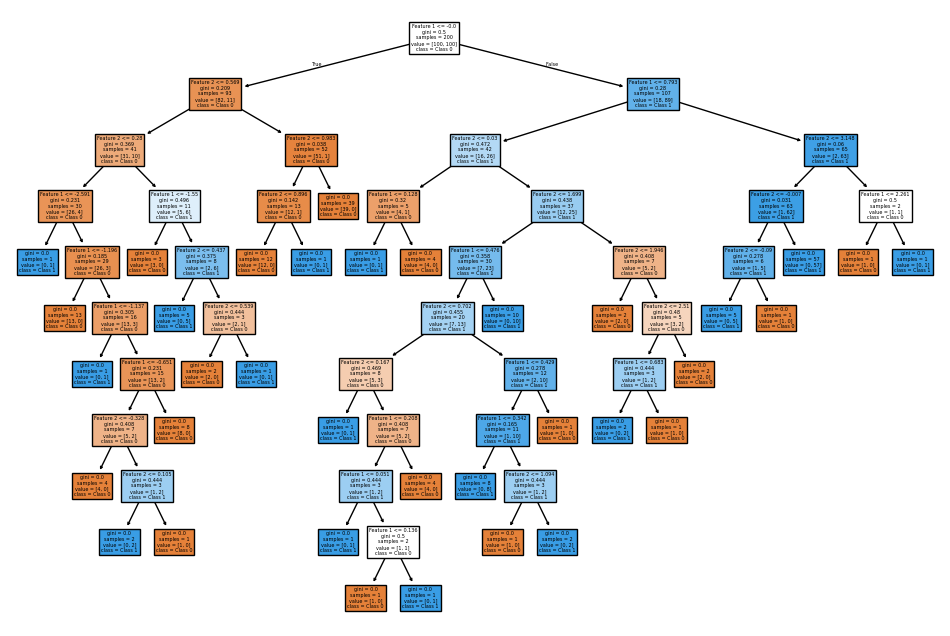

In [28]:
plt.figure(figsize=(12,8))

plot_tree(
    model,
    filled=True,
    feature_names=["Feature 1", "Feature 2"],
    class_names=["Class 0", "Class 1"]
)

plt.show()

## Conclusion

- Decision Trees learn by repeatedly splitting the data based on feature values.
- They are easy to understand and visualize.
- They can be used for both classification and regression problems.
- Decision Trees can overfit the training data, which is why algorithms like Random Forest were developed.